# Week3_ex1_analysis - Flux Linkage of a 5-Turn Ring Beside a Straight Wire

![Week3_ex1 result](Images/Week3_ex1_result_image.png)

A 400 mm copper wire (10 mm diameter, 100 A) runs along x and touches both x faces of the region, so it acts like an infinite wire. A 5-turn ring coil (36-sided, 19.75-20.25 mm radius, 0.5 mm thick, 1.5 mm turn pitch) lies in the same plane as the wire, centered 100 mm away. The wire does not go through the ring.

There's a closed-form answer here and nothing unusual shows up, so this is a short check without hypotheses. The only real work is matching the theory to the actual model geometry (36-sided ring, finite conductor width, stacked turns), because those corrections turn out to be the same size as the FEM error.

$$\Lambda = N\,\mu_0 I\left(d-\sqrt{d^2-a^2}\right), \qquad d = 100\ \text{mm},\ a = 20\ \text{mm},\ N = 5$$

This is just the $1/\rho$ field of the wire integrated over a disk of radius $a$, times $N$.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Model parameters, taken from the design variables of the solved project
mu0 = 4e-7 * np.pi
I = 100.0                     # A
d = 0.100                     # m, ring center to wire axis (line_length / 4)
N = 5
r_in, r_out = 19.75e-3, 20.25e-3                    # m, ring radii (circumradius of the 36-sided polyhedron)
a = 0.5 * (r_in + r_out)
z_turns = (np.arange(N) - (N - 1) / 2) * 1.5e-3     # m, turn heights after the stack is centered on z = 0

# 2. FEM flux linkage, read once from Winding Table 1 in the AEDT GUI (Setup1 : LastAdaptive, Field Precision = 10)
lam_fem = -1.2628e-6          # Wb, sign only reflects the terminal orientation, so magnitudes are compared below

In [2]:
# 3. Flux through one closed polygon loop at height z, using Phi = loop integral of A.
#    For an infinite wire along x, A only has an x-component, A_x = -mu0*I/(2*pi) * ln(rho),
#    so the polygon case is exact without having to integrate B over the polygon area.
def loop_flux(R, z, n_sides, n_sub=100):
    ang = -np.pi / 2 + 2 * np.pi * np.arange(n_sides + 1) / n_sides   # first vertex points away from the wire, like the polyhedron origin
    x = R * np.cos(ang)
    y = -d + R * np.sin(ang)
    t = (np.arange(n_sub) + 0.5) / n_sub
    phi = 0.0
    for k in range(n_sides):
        ys = y[k] + (y[k + 1] - y[k]) * t
        Ax = -mu0 * I / (2 * np.pi) * np.log(np.sqrt(ys**2 + z**2))
        phi += np.sum(Ax) * (x[k + 1] - x[k]) / n_sub
    return abs(phi)


# 4. Stranded winding -> flux averaged over the conductor width, summed over the stacked turns
def stack_linkage(radii, n_sides):
    return sum(np.mean([loop_flux(R, z, n_sides) for R in radii]) for z in z_turns)


R_avg = np.linspace(r_in, r_out, 21)
lam_theory = {
    "Closed form (circle, a = 20 mm, all turns at z = 0)": N * mu0 * I * (d - np.sqrt(d**2 - a**2)),
    "Circle, width and stack height included": stack_linkage(R_avg, 360),
    "36-gon, inner edge only (19.75 mm)": stack_linkage([r_in], 36),
    "36-gon, outer edge only (20.25 mm)": stack_linkage([r_out], 36),
    "36-gon, width and stack height included": stack_linkage(R_avg, 36),
}

# 5. FEM error against each theory variant
pd.DataFrame({
    "Theory [uWb]": [v * 1e6 for v in lam_theory.values()],
    "FEM [uWb]": abs(lam_fem) * 1e6,
    "FEM error [%]": [(abs(lam_fem) - v) / v * 100 for v in lam_theory.values()],
}, index=list(lam_theory.keys())).round(4)

,Theory [uWb],FEM [uWb],FEM error [%]
"Closed form (circle, a = 20 mm, all turns at z = 0)",1.2695,1.2628,-0.5247
"Circle, width and stack height included",1.2689,1.2628,-0.4785
"36-gon, inner edge only (19.75 mm)",1.2307,1.2628,2.6093
"36-gon, outer edge only (20.25 mm)",1.2945,1.2628,-2.4452
"36-gon, width and stack height included",1.2624,1.2628,0.0286


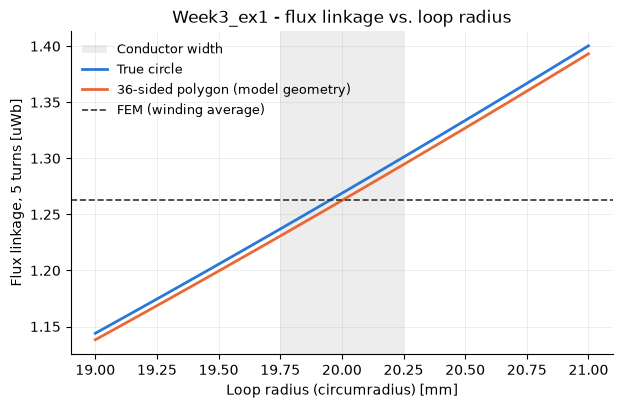

In [3]:
# 6. Linkage vs. loop radius for a circle and for the 36-gon, with the conductor width shaded
R_scan = np.linspace(19.0e-3, 21.0e-3, 41)
lam_circle = [stack_linkage([R], 360) * 1e6 for R in R_scan]
lam_poly = [stack_linkage([R], 36) * 1e6 for R in R_scan]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.axvspan(r_in * 1e3, r_out * 1e3, color="#9e9e9e", alpha=0.18, lw=0, label="Conductor width")
ax.plot(R_scan * 1e3, lam_circle, color="#2a78d6", lw=2, label="True circle")
ax.plot(R_scan * 1e3, lam_poly, color="#eb6834", lw=2, label="36-sided polygon (model geometry)")
ax.axhline(abs(lam_fem) * 1e6, color="#333333", lw=1.2, ls="--", label="FEM (winding average)")
ax.set_xlabel("Loop radius (circumradius) [mm]")
ax.set_ylabel("Flux linkage, 5 turns [uWb]")
ax.set_title("Week3_ex1 - flux linkage vs. loop radius")
ax.grid(alpha=0.25, lw=0.6)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, fontsize=9)

os.makedirs("Images", exist_ok=True)
plt.savefig("Images/Week3_ex1_flux_linkage_vs_radius.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion

After matching the theory to the model geometry, FEM and theory agree to about +0.03%, which is only a few times the read-out resolution of the table (the value is shown to 5 significant digits, roughly 0.004%).

The plain closed form comes out 0.5% high, and almost all of that is the 36-sided ring: a regular 36-gon has about 0.51% less area than its circumscribed circle, and the polyhedron radius here is the circumradius. The finite stack height barely matters (turns sit at most 3 mm off the wire plane, a ~0.05% effect).

The bigger lesson is the conductor width. Taking the inner or outer edge of the ring as "the" loop shifts the prediction by about +/-2.5%, which is far larger than any mesh error in this model. Because coil_2 is a stranded winding, AEDT averages the linkage over the conductor cross-section, and the prediction only lands on the FEM value once the theory does the same averaging.

One thing to note about the original notebook: the data table uses line_length as its x-axis, but there's no parametric sweep behind it, so the table only has a single row at 400 mm. That doesn't affect this check, and no further analysis is needed.